In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm

In [39]:
Nor_CCN_CDNC_ds = xr.open_dataset('/share/pech2273/NorESM_CCN_CDNC.nc')
CDNC_Nor = Nor_CCN_CDNC_ds.CDNC

In [40]:
da_rev = CDNC_Nor.isel(lev=slice(None, None, -1))

# Boolean mask of non-zero values
mask = da_rev > 0

# Get index of first True along lev
first_idx_rev = mask.argmax(dim="lev")

# Handle cases where all values are zero
has_cloud = mask.any(dim="lev")
first_idx_rev = first_idx_rev.where(has_cloud)

# Convert index back to original lev numbering
nlev = CDNC_Nor.sizes["lev"]
first_level_index = (nlev - 1) - first_idx_rev

In [142]:
cdnc_cloudmax = CDNC_Nor.max("lev")
# Mask where at least one valid value exists
has_data = CDNC_Nor.notnull().any("lev")

# Compute argmax safely
lev_index_at_max = CDNC_Nor.fillna(-np.inf).argmax("lev")

# Mask out columns that were originally all NaN
lev_index_at_max = lev_index_at_max.where(has_data)


In [144]:
len(lev_index_at_max.sel(station = 'SMR-II').dropna('time'))

3520

In [149]:
ccn_cloudmax = (
    Nor_CCN_CDNC_ds.CCN
    .isel(lev=lev_index_at_max.fillna(0).astype(int))
    .where(lev_index_at_max.notnull())
)

In [71]:
safe_index = first_level_index.fillna(0).astype(int)

cdnc_cloudbase = (
    CDNC_Nor
    .isel(lev=safe_index)
    .where(first_level_index.notnull())
)
CCN_cloudbase = (
    Nor_CCN_CDNC_ds.CCN.isel(lev=safe_index)
    .where(first_level_index.notnull())
)

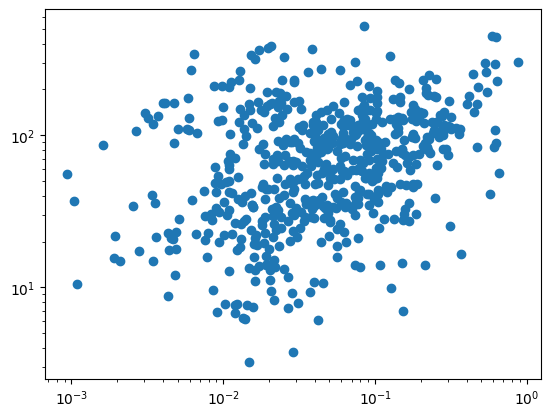

In [90]:
plt.scatter(CCN_cloudbase.sel(station = 'SGP').isel(radius = 30),cdnc_cloudbase.sel(station = 'SGP'))
plt.xscale('log')
plt.yscale('log')


In [97]:
stations = Nor_CCN_CDNC_ds.station.values
radii = Nor_CCN_CDNC_ds.radius.values
bins = np.logspace(0, 4, 101)  # 10^0=1, 10^4=10000'
# Pre-allocate Dataset
reg_ds_cb = xr.Dataset(
    data_vars={
        "slope":   (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "r_value": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "std_err": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "intercept": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),

    },
    coords={
        "station": stations,
        "radius": radii
    }
)
#reg_ds_cb = xr.open_dataset('/share/pech2273/NorESM_Susceptibility_All_level.nc')
Downloaded = False
# Loop over stations and radii
if Downloaded is False:
    for s, station in enumerate(stations):
        for r in range(len(radii)):
            CCN_slice = CCN_cloudbase.sel(station=station).isel(radius=r)
            CDNC_slice = cdnc_cloudbase.sel(station=station)
            valid = np.isfinite(CCN_slice.values) & (CCN_slice.values > bins[0]) & (CCN_slice.values < bins[-1])

            if valid.sum() < 2:
                continue
            # Bin by CCN
            CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
            CDNC_binned = CDNC_slice.groupby_bins(CCN_slice, bins).mean()
    
            x = np.log10(CCN_binned.values)
            y = np.log10(CDNC_binned.values)
    
            mask = np.isfinite(x) & np.isfinite(y)
    
            if mask.sum() < 2:
                continue  # avoid linregress crash
    
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                x[mask], y[mask]
            )
    
            # Assign into Dataset
            reg_ds_cb["slope"][s, r] = slope
            reg_ds_cb["r_value"][s, r] = r_value
            reg_ds_cb["std_err"][s, r] = std_err
            reg_ds_cb["intercept"][s, r] = std_err

In [150]:
CCN_slice = ccn_cloudmax.sel(station=station).isel(radius=r)
CCN_slice

<xarray.DataArray 'CCN' (time: 8761)> Size: 70kB
array([182.37979777, 177.26900975, 197.84642314, ...,          nan,
        10.06114732,          nan], shape=(8761,))
Coordinates:
  * time     (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
    station  <U8 32B 'ZEP'
    lev      (time) float64 70kB 859.5 887.0 912.6 936.2 ... 3.643 763.4 3.643
    radius   float64 8B 1.0

In [151]:
stations = Nor_CCN_CDNC_ds.station.values
radii = Nor_CCN_CDNC_ds.radius.values
bins = np.logspace(0, 4, 101)  # 10^0=1, 10^4=10000'
# Pre-allocate Dataset
reg_ds_cmax = xr.Dataset(
    data_vars={
        "slope":   (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "r_value": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "std_err": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),
        "intercept": (("station", "radius"), np.full((len(stations), len(radii)), np.nan)),

    },
    coords={
        "station": stations,
        "radius": radii
    }
)
#reg_ds_cmax = xr.open_dataset('/share/pech2273/NorESM_Susceptibility_All_level.nc')
Downloaded = False
# Loop over stations and radii
if Downloaded is False:
    for s, station in enumerate(stations):
        for r in range(len(radii)):
            CCN_slice = ccn_cloudmax.sel(station=station).isel(radius=r)
            CDNC_slice = cdnc_cloudmax.sel(station=station)
            valid = np.isfinite(CCN_slice.values) & (CCN_slice.values > bins[0]) & (CCN_slice.values < bins[-1])

            if valid.sum() < 2:
                continue
            # Bin by CCN
            CCN_binned = CCN_slice.groupby_bins(CCN_slice, bins).mean()
            CDNC_binned = CDNC_slice.groupby_bins(CCN_slice, bins).mean()
    
            x = np.log10(CCN_binned.values)
            y = np.log10(CDNC_binned.values)
    
            mask = np.isfinite(x) & np.isfinite(y)
    
            if mask.sum() < 2:
                continue  # avoid linregress crash
    
            slope, intercept, r_value, p_value, std_err = stats.linregress(
                x[mask], y[mask]
            )
    
            # Assign into Dataset
            reg_ds_cmax["slope"][s, r] = slope
            reg_ds_cmax["r_value"][s, r] = r_value
            reg_ds_cmax["std_err"][s, r] = std_err
            reg_ds_cmax["intercept"][s, r] = std_err

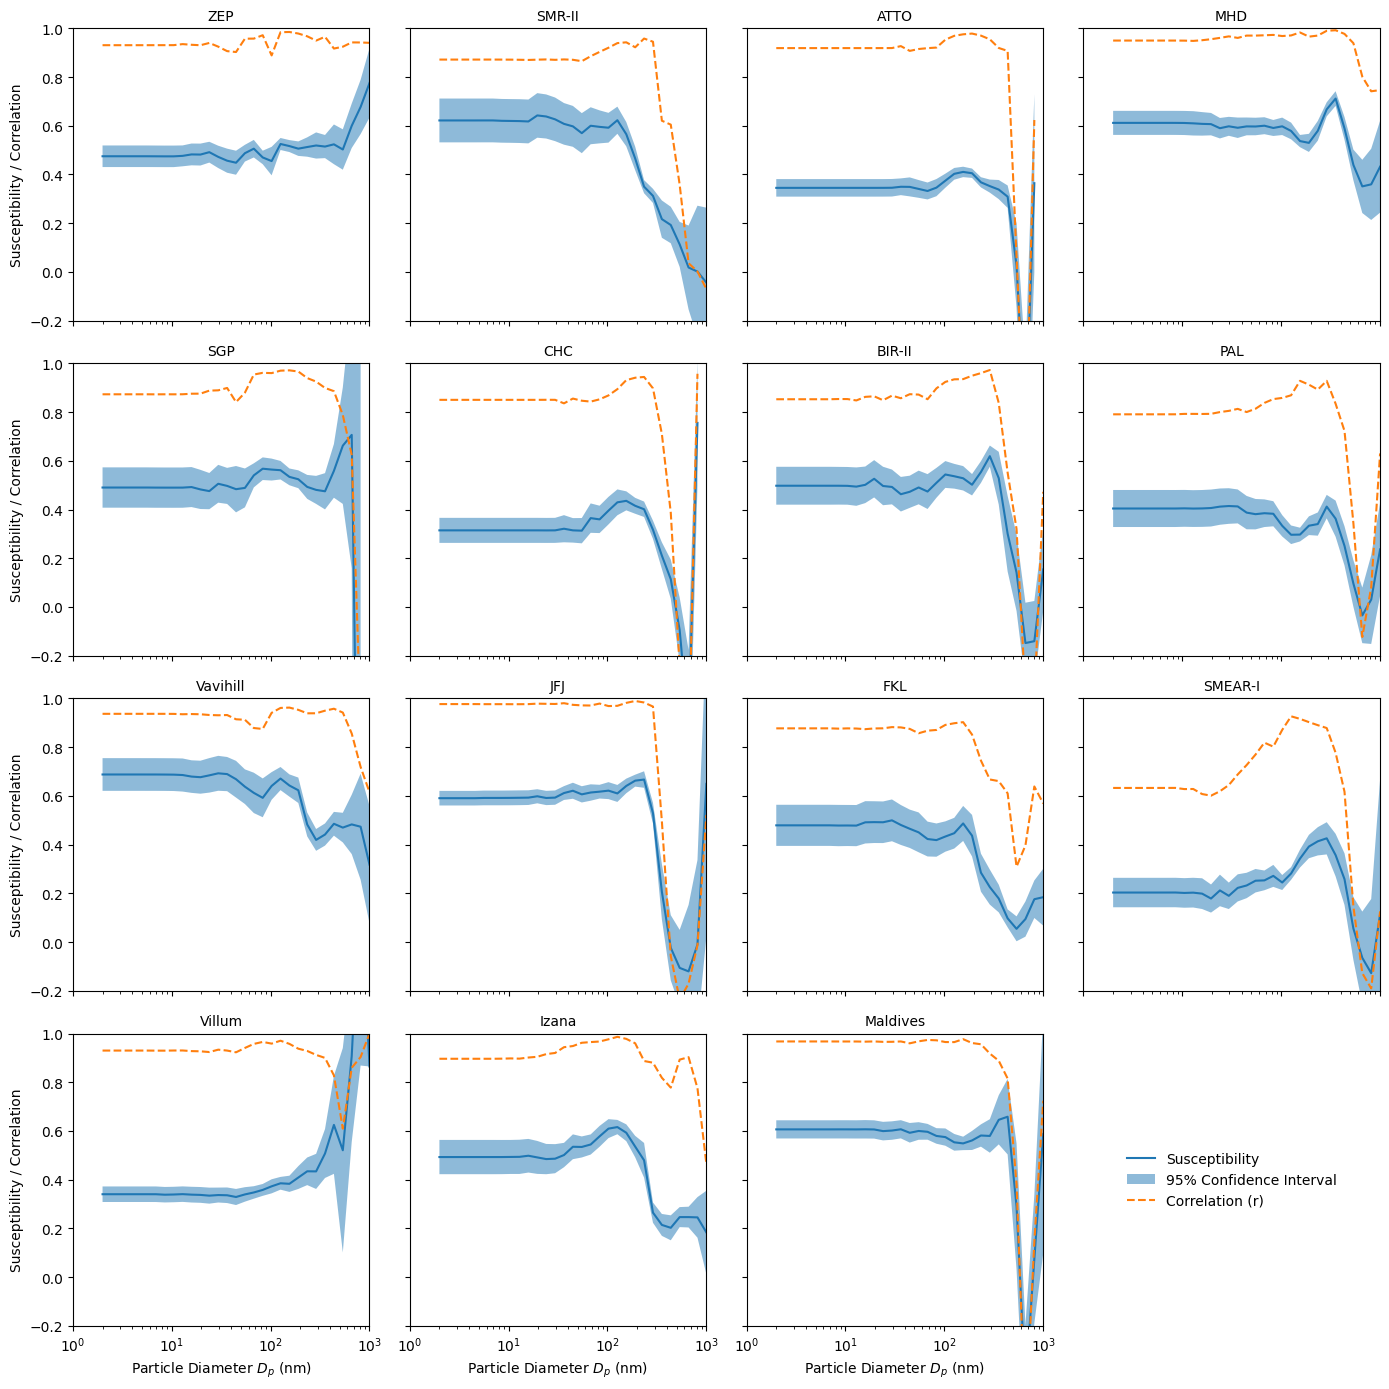

In [94]:
stations = reg_ds.station.values
n_stations = len(stations)

fig, axes = plt.subplots(
    4, 4,
    figsize=(14, 14),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):

    ax = axes[i]

    slope = reg_ds['slope'].sel(station=station)
    std_err = reg_ds['std_err'].sel(station=station)
    r_val = reg_ds['r_value'].sel(station=station)

    ax.plot(radii * 2, slope, label='Susceptibility')
    ax.fill_between(
        radii * 2,
        slope - 1.96 * std_err,
        slope + 1.96 * std_err,
        alpha=0.5,
        label='95% Confidence Interval'
    )
    ax.plot(
        radii * 2,
        r_val,
        '--',
        label='Correlation (r)'
    )

    ax.set_title(station, fontsize=10)
    ax.set_xscale('log')
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# --- Last panel used only for legend ---
legend_ax = axes[-1]
legend_ax.axis('off')

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=10
)

# Axis labels (only on outer edges)
for ax in axes[12:16]:
    ax.set_xlabel('Particle Diameter $D_p$ (nm)')

for ax in axes[::4]:
    ax.set_ylabel('Susceptibility / Correlation')

plt.tight_layout()
plt.show()


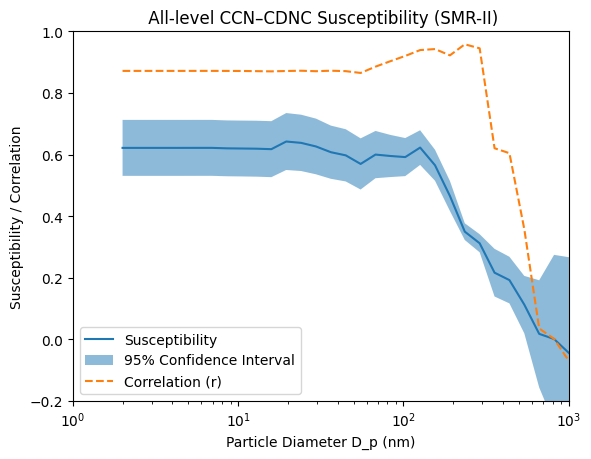

In [95]:
plt.plot(radii*2, reg_ds['slope'].sel(station = 'SMR-II'), label = 'Susceptibility')
plt.fill_between(radii*2,
                 reg_ds['slope'].sel(station = 'SMR-II')-1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 reg_ds['slope'].sel(station = 'SMR-II')+1.98*reg_ds['std_err'].sel(station = 'SMR-II'),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(radii*2, reg_ds['r_value'].sel(station = 'SMR-II'), '--', label = 'Correlation (r)')
plt.legend()
plt.title(" All-level CCN–CDNC Susceptibility (SMR-II)")
plt.xlabel('Particle Diameter D_p (nm)')
plt.ylabel('Susceptibility / Correlation')
plt.ylim([-0.2, 1])
plt.xlim([1,1000])
plt.xscale('log')

In [99]:
reg_ds_all_lev = xr.open_dataset('/share/pech2273/NorESM_Susceptibility_All_level.nc')
reg_ds_summed = xr.open_dataset('/share/pech2273/NorESM_Column_Susceptibility')

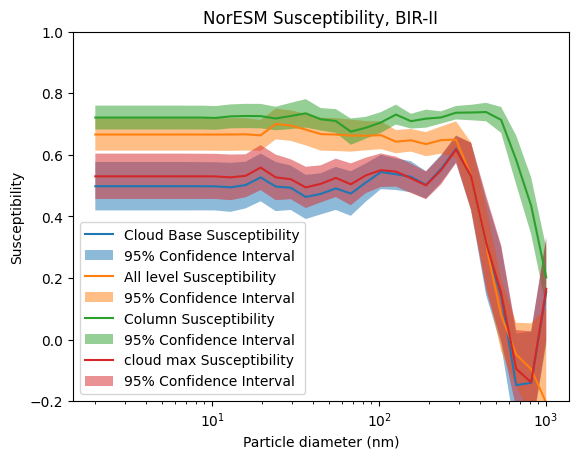

In [154]:
station = 'BIR-II'
plt.plot(radii*2, reg_ds_cb['slope'].sel(station = station), label = 'Cloud Base Susceptibility')
plt.fill_between(radii*2,
                 reg_ds_cb['slope'].sel(station = station)-1.98*reg_ds_cb['std_err'].sel(station = station),
                 reg_ds_cb['slope'].sel(station = station)+1.98*reg_ds_cb['std_err'].sel(station = station),
                 alpha = 0.5, label = '95% Confidence Interval')

plt.plot(radii*2, reg_ds_all_lev['slope'].sel(station = station), label = 'All level Susceptibility')
plt.fill_between(radii*2,
                 reg_ds_all_lev['slope'].sel(station = station)-1.98*reg_ds_all_lev['std_err'].sel(station = station),
                 reg_ds_all_lev['slope'].sel(station = station)+1.98*reg_ds_all_lev['std_err'].sel(station = station),
                 alpha = 0.5, label = '95% Confidence Interval')

plt.plot(radii*2, reg_ds_summed['slope'].sel(station = station), label = 'Column Susceptibility')
plt.fill_between(radii*2,
                 reg_ds_summed['slope'].sel(station = station)-1.98*reg_ds_summed['std_err'].sel(station = station),
                 reg_ds_summed['slope'].sel(station = station)+1.98*reg_ds_summed['std_err'].sel(station = station),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(radii*2, reg_ds_cmax['slope'].sel(station = station), label = 'cloud max Susceptibility')
plt.fill_between(radii*2,
                 reg_ds_cmax['slope'].sel(station = station)-1.98*reg_ds_cmax['std_err'].sel(station = station),
                 reg_ds_cmax['slope'].sel(station = station)+1.98*reg_ds_cmax['std_err'].sel(station = station),
                 alpha = 0.5, label = '95% Confidence Interval')

plt.xscale('log')
plt.ylim([-0.2,1])
plt.xlabel('Particle diameter (nm)')
plt.ylabel('Susceptibility')
plt.title(f'NorESM Susceptibility, {station}')
plt.legend()

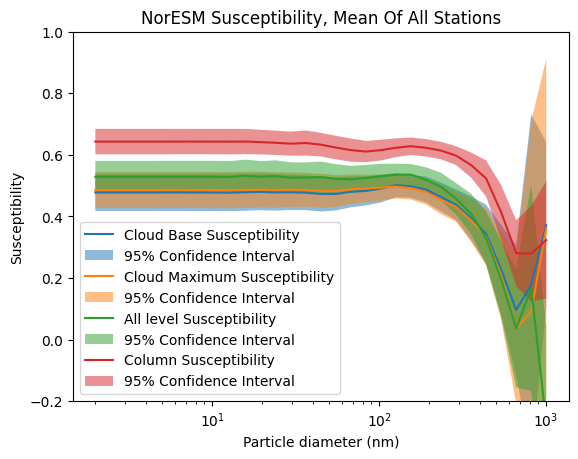

In [153]:
plt.plot(radii*2, reg_ds_cb['slope'].mean('station'), label = 'Cloud Base Susceptibility')
plt.fill_between(radii*2,
                 reg_ds_cb['slope'].mean('station')-1.98*reg_ds_cb['std_err'].mean('station'),
                 reg_ds_cb['slope'].mean('station')+1.98*reg_ds_cb['std_err'].mean('station'),
                 alpha = 0.5, label = '95% Confidence Interval')
plt.plot(radii*2, reg_ds_cmax['slope'].mean('station'), label = 'Cloud Maximum Susceptibility')
plt.fill_between(radii*2,
                 reg_ds_cmax['slope'].mean('station')-1.98*reg_ds_cmax['std_err'].mean('station'),
                 reg_ds_cmax['slope'].mean('station')+1.98*reg_ds_cmax['std_err'].mean('station'),
                 alpha = 0.5, label = '95% Confidence Interval')

plt.plot(radii*2, reg_ds_all_lev['slope'].mean('station'), label = 'All level Susceptibility')
plt.fill_between(radii*2,
                 reg_ds_all_lev['slope'].mean('station')-1.98*reg_ds_all_lev['std_err'].mean('station'),
                 reg_ds_all_lev['slope'].mean('station')+1.98*reg_ds_all_lev['std_err'].mean('station'),
                 alpha = 0.5, label = '95% Confidence Interval')

plt.plot(radii*2, reg_ds_summed['slope'].mean('station'), label = 'Column Susceptibility')
plt.fill_between(radii*2,
                 reg_ds_summed['slope'].mean('station')-1.98*reg_ds_summed['std_err'].mean('station'),
                 reg_ds_summed['slope'].mean('station')+1.98*reg_ds_summed['std_err'].mean('station'),
                 alpha = 0.5, label = '95% Confidence Interval')

plt.xscale('log')
plt.ylim([-0.2,1])
plt.xlabel('Particle diameter (nm)')
plt.ylabel('Susceptibility')
plt.title(f'NorESM Susceptibility, Mean Of All Stations')
plt.legend()

In [ ]:
plt.hist(cdnc_cloudbase.notnull())

In [169]:
cdnc_cloudmax.sel(station = 'SMR-II').dropna('time')-cdnc_cloudbase.sel(station = 'SMR-II').dropna('time')

<xarray.DataArray 'CDNC' (time: 3520)> Size: 14kB
array([0., 0., 0., ..., 0., 0., 0.], shape=(3520,), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 28kB 2012-01-02T06:00:00 ... 2015-01-01
    station  <U8 32B 'SMR-II'
    lev      (time) float64 28kB 936.2 957.5 957.5 957.5 ... 992.6 992.6 992.6